# One-Shot Percussion Classification — 20 Features

Multi-run training (**N = 5**) with different random seeds on the **same train/validation split**.

This notebook mirrors the structure of the uploaded `train_42feats_multirun.ipynb`, but uses the **current top-20 feature subset** obtained from the multi-run feature-importance analysis.

## Current top-20 feature list
```python
['onset_sum', 'rms_std', 'flux_mean', 'mfcc03', 'mfcc04', 'onset_std', 'contrast_b6', 'mfcc02', 'rms_mean', 'onset_mean', 'mfcc01', 'onset_max', 'contrast_b2', 'bandwidth_mean', 'zcr_mean', 'mfcc05', 'centroid_mean', 'mfcc08', 'rolloff_mean', 'flatness_mean']
```

## What this notebook does
- Loads the same CSV file
- Keeps the same fixed split across runs
- Uses the same ANN architecture and callbacks
- Trains the model five times with different seeds
- Reports mean ± std across runs
- Saves the best-performing run, scaler, label encoder, histories, and plots


In [5]:
import os
from google.colab import drive

# If the directory exists and has files, remove them so we can mount
if os.path.exists('/content/drive') and os.listdir('/content/drive'):
    !rm -rf /content/drive

drive.mount('/content/drive', force_remount=True)

Mounted at /content/drive


## 1. Imports and global config

In [8]:

import os, random, pickle, joblib
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow.keras.models import Model, load_model
from tensorflow.keras.layers import Dense, Dropout, Input, BatchNormalization
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import (
    EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
)
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    classification_report, confusion_matrix, f1_score
)
import matplotlib.pyplot as plt

# ------------------------------------------------------------------
# PATHS — edit to match your Drive layout
# ------------------------------------------------------------------
CSV_PATH = '/content/drive/MyDrive/Feature Importance Analysis/one_shot_features_clean_V4.csv'
SAVE_DIR = '/content/drive/MyDrive/SavedModels/20feats_runs'
os.makedirs(SAVE_DIR, exist_ok=True)

# ------------------------------------------------------------------
# CURRENT TOP-20 FEATURES (from multi-run importance analysis)
# ------------------------------------------------------------------
TOP20_FEATURES = [
    'onset_sum',
    'rms_std',
    'flux_mean',
    'mfcc03',
    'mfcc04',
    'onset_std',
    'contrast_b6',
    'mfcc02',
    'rms_mean',
    'onset_mean',
    'mfcc01',
    'onset_max',
    'contrast_b2',
    'bandwidth_mean',
    'zcr_mean',
    'mfcc05',
    'centroid_mean',
    'mfcc08',
    'rolloff_mean',
    'flatness_mean',
]

# ------------------------------------------------------------------
# EXPERIMENT CONFIG
# ------------------------------------------------------------------
RUN_SEEDS   = [42, 123, 7, 2024, 512]
N_RUNS      = len(RUN_SEEDS)
SPLIT_SEED  = 42
TEST_SIZE   = 0.2
EPOCHS      = 200
BATCH_SIZE  = 32
LR_INIT     = 1e-3
PATIENCE_ES = 15
PATIENCE_LR = 8
DROPOUT     = 0.3


## 2. Data loading and preprocessing

Null values in numeric columns are imputed with the column-wise mean, consistent with the preprocessing used in the 42-feature notebook and the current paper draft.


In [9]:

df = pd.read_csv(CSV_PATH)

print('Null values (before imputation):')
print(df.isnull().sum()[df.isnull().sum() > 0])

df_filled = df.copy()
numeric_columns = df.select_dtypes(include=[np.number]).columns
df_filled[numeric_columns] = df_filled[numeric_columns].fillna(
    df_filled[numeric_columns].mean()
)

print('\nAny remaining null values? ', df_filled.isnull().sum().sum())
print('Data shape:', df_filled.shape)
df_filled.head()


Null values (before imputation):
hpi_ratio    62
dtype: int64

Any remaining null values?  0
Data shape: (6435, 44)


,mfcc01,mfcc02,mfcc03,mfcc04,mfcc05,mfcc06,mfcc07,mfcc08,mfcc09,mfcc10,...,contrast_b7,onset_mean,onset_std,onset_max,onset_sum,attack_time,attack_slope,hpi_ratio,label,filename
0,-375.80786,40.318410,2.222316,25.521338,17.871218,14.569949,6.145129,8.773415,7.858817,10.529112,...,42.412579,0.337117,0.525832,3.022757,28.654934,0.267029,22.350317,0.705611,Kick,053.vubeatz - Kick-19.wav
1,-399.84290,105.145590,5.199309,10.956247,24.178602,15.623933,7.570135,11.298717,8.760970,10.446151,...,33.525089,0.210629,0.190053,0.680425,9.688943,0.185760,101.448700,1.952946,Kick,061.vubeatz - Kick-27.wav
2,-442.54538,101.096000,42.732346,34.081097,21.172230,19.151922,13.419593,12.518649,8.550889,11.492721,...,30.396937,0.087409,0.201809,1.219732,3.321545,0.000000,0.000000,1.492114,Kick,Oversampled_SH2_kick_trap_heat.wav
3,-517.26240,59.168682,37.639400,28.265085,18.350937,15.631050,10.798821,11.485106,8.637713,10.242297,...,36.001919,0.031550,0.100115,0.912067,3.028791,0.000000,0.000000,1.699616,Kick,WLUB2 Kick 12.wav
4,-386.06960,169.830570,26.742740,34.934870,16.483923,17.485287,10.294847,10.084108,5.280774,6.466370,...,23.650770,0.083986,0.172245,0.901509,2.267620,0.000000,0.000000,0.847363,Kick,M - SATYR KICK.wav


In [10]:

# Features and labels
feature_cols_all = [c for c in df_filled.columns if c not in ('label', 'filename')]

missing = [f for f in TOP20_FEATURES if f not in feature_cols_all]
if missing:
    raise ValueError(f'These requested top-20 features are missing from the CSV: {missing}')

X = df_filled[TOP20_FEATURES].values
y = df_filled['label'].values

print(f'Selected feature matrix: {X.shape}')
print('Selected features in order:')
for i, f in enumerate(TOP20_FEATURES, 1):
    print(f'  {i:2d}. {f}')

label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)
class_names = list(label_encoder.classes_)
num_classes = len(class_names)

y_cat = tf.keras.utils.to_categorical(y_encoded, num_classes=num_classes)

print('\nClasses:', class_names)
print('Number of classes:', num_classes)


Selected feature matrix: (6435, 20)
Selected features in order:
   1. onset_sum
   2. rms_std
   3. flux_mean
   4. mfcc03
   5. mfcc04
   6. onset_std
   7. contrast_b6
   8. mfcc02
   9. rms_mean
  10. onset_mean
  11. mfcc01
  12. onset_max
  13. contrast_b2
  14. bandwidth_mean
  15. zcr_mean
  16. mfcc05
  17. centroid_mean
  18. mfcc08
  19. rolloff_mean
  20. flatness_mean

Classes: ['Bass', 'Clap', 'Cymbal', 'Hat', 'Kick', 'Rims', 'Snare']
Number of classes: 7


In [11]:

# z-score normalization — fit on ALL data (consistent with the uploaded 42-feature notebook)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Fixed train/validation split for ALL runs
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y_cat,
    test_size=TEST_SIZE,
    random_state=SPLIT_SEED,
    stratify=y_encoded
)

print('Train shape:', X_train.shape, y_train.shape)
print('Valid shape:', X_test.shape, y_test.shape)


Train shape: (5148, 20) (5148, 7)
Valid shape: (1287, 20) (1287, 7)


## 3. Model architecture

Three fully connected hidden blocks (256, 128, 64), each with BatchNorm + Dropout(0.3) + ReLU, followed by a 64-unit embedding layer and a softmax classifier.


In [12]:

def create_enhanced_model(input_dim, num_classes, dropout=DROPOUT):
    inp = Input(shape=(input_dim,), name='input_layer')

    x = Dense(256, activation='relu', name='dense_1')(inp)
    x = BatchNormalization(name='bn_1')(x)
    x = Dropout(dropout, name='dropout_1')(x)

    x = Dense(128, activation='relu', name='dense_2')(x)
    x = BatchNormalization(name='bn_2')(x)
    x = Dropout(dropout, name='dropout_2')(x)

    x = Dense(64, activation='relu', name='dense_3')(x)
    x = BatchNormalization(name='bn_3')(x)
    x = Dropout(dropout, name='dropout_3')(x)

    emb = Dense(64, activation='relu', name='embedding_layer')(x)
    out = Dense(num_classes, activation='softmax', name='output_layer')(emb)

    model = Model(inputs=inp, outputs=out, name='ann_20feats')
    model.compile(
        optimizer=Adam(learning_rate=LR_INIT),
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )
    return model

model = create_enhanced_model(X_train.shape[1], num_classes)
model.summary()


Model: "ann_20feats"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 20)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 256)            │         5,376 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn_1 (BatchNormalization)       │ (None, 256)            │         1,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn_2 (BatchNormalization)       │ (None, 128)            │           512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn_3 (BatchNormalization)       │ (None, 64)             │           256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ embedding_layer (Dense)         │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output_layer (Dense)            │ (None, 7)              │           455 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 52,935 (206.78 KB)

 Trainable params: 52,039 (203.28 KB)

 Non-trainable params: 896 (3.50 KB)

## 4. Helper function — single training run

Seeds all sources of randomness, trains one model, saves its checkpoint, and returns metrics + history.


In [13]:

def set_all_seeds(seed):
    os.environ['PYTHONHASHSEED'] = str(seed)
    random.seed(seed)
    np.random.seed(seed)
    tf.random.set_seed(seed)
    tf.keras.utils.set_random_seed(seed)

def run_one(run_id, seed, X_tr, y_tr, X_va, y_va):
    print(f'\n{"="*60}')
    print(f'RUN {run_id+1}/{N_RUNS}  |  seed = {seed}')
    print('=' * 60)

    tf.keras.backend.clear_session()
    set_all_seeds(seed)

    model = create_enhanced_model(X_tr.shape[1], num_classes)

    ckpt_path = f'{SAVE_DIR}/run{run_id+1:02d}_seed{seed}.h5'

    callbacks = [
        EarlyStopping(
            monitor='val_accuracy',
            patience=PATIENCE_ES,
            restore_best_weights=True,
            verbose=1
        ),
        ReduceLROnPlateau(
            monitor='val_loss',
            factor=0.5,
            patience=PATIENCE_LR,
            min_lr=1e-6,
            verbose=1
        ),
        ModelCheckpoint(
            ckpt_path,
            monitor='val_accuracy',
            save_best_only=True,
            verbose=0
        )
    ]

    history = model.fit(
        X_tr, y_tr,
        validation_data=(X_va, y_va),
        epochs=EPOCHS,
        batch_size=BATCH_SIZE,
        verbose=1,
        callbacks=callbacks
    )

    # reload best checkpoint for exact evaluation
    best_model = load_model(ckpt_path, compile=False)
    best_model.compile(
        optimizer=Adam(learning_rate=LR_INIT),
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )

    val_loss, val_acc = best_model.evaluate(X_va, y_va, verbose=0)

    y_true = np.argmax(y_va, axis=1)
    y_pred = np.argmax(best_model.predict(X_va, verbose=0), axis=1)

    macro_f1 = f1_score(y_true, y_pred, average='macro')
    weighted_f1 = f1_score(y_true, y_pred, average='weighted')

    per_class_f1 = f1_score(y_true, y_pred, average=None)
    per_class_f1_dict = {f'f1_{cname}': score for cname, score in zip(class_names, per_class_f1)}

    best_epoch = int(np.argmax(history.history['val_accuracy']) + 1)
    total_epochs = len(history.history['loss'])

    lr_reductions = 0
    lrs = history.history.get('learning_rate', [])
    for i in range(1, len(lrs)):
        if lrs[i] < lrs[i-1]:
            lr_reductions += 1

    result = {
        'run': run_id + 1,
        'seed': seed,
        'val_acc': float(val_acc),
        'val_loss': float(val_loss),
        'macro_f1': float(macro_f1),
        'weighted_f1': float(weighted_f1),
        'best_epoch': best_epoch,
        'total_epochs': total_epochs,
        'lr_reductions': lr_reductions,
        **per_class_f1_dict
    }

    return result, history.history, ckpt_path


## 5. Run all 5 training runs

In [14]:

all_results   = []
all_histories = []
all_ckpts     = []

for run_id, seed in enumerate(RUN_SEEDS):
    result, hist, ckpt = run_one(run_id, seed, X_train, y_train, X_test, y_test)
    all_results.append(result)
    all_histories.append(hist)
    all_ckpts.append(ckpt)

df_runs = pd.DataFrame(all_results)
df_runs



RUN 1/5  |  seed = 42
Epoch 1/200
142/161 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.4546 - loss: 1.4838

161/161 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.5956 - loss: 1.1096 - val_accuracy: 0.7117 - val_loss: 0.8713 - learning_rate: 0.0010
Epoch 2/200
156/161 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7181 - loss: 0.7816

161/161 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7263 - loss: 0.7334 - val_accuracy: 0.7910 - val_loss: 0.5669 - learning_rate: 0.0010
Epoch 3/200
154/161 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7464 - loss: 0.6781

161/161 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.7599 - loss: 0.6447 - val_accuracy: 0.8267 - val_loss: 0.4972 - learning_rate: 0.0010
Epoch 4/200
153/161 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7826 - loss: 0.5897

161/161 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.7865 - loss: 0.5761 - val_accuracy: 0.8368 - val_loss: 0.4582 - learning_rate: 0.0010
Epoch 5/200
153/161 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.7971 - loss: 0.5555

...

161/161 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8996 - loss: 0.2726 - val_accuracy: 0.8881 - val_loss: 0.3547 - learning_rate: 5.0000e-04
Epoch 36/200
151/161 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8972 - loss: 0.2738

161/161 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8943 - loss: 0.2789 - val_accuracy: 0.8897 - val_loss: 0.3542 - learning_rate: 5.0000e-04
Epoch 37/200
152/161 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9027 - loss: 0.2723

161/161 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8994 - loss: 0.2718 - val_accuracy: 0.8904 - val_loss: 0.3552 - learning_rate: 5.0000e-04
Epoch 38/200
161/161 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8972 - loss: 0.2684 - val_accuracy: 0.8897 - val_loss: 0.3698 - learning_rate: 5.0000e-04
Epoch 39/200
161/161 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9025 - loss: 0.2645 - val_accuracy: 0.8904 - val_loss: 0.3609 - learning_rate: 5.0000e-04
Epoch 40/200
161/161 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9005 - loss: 0.2627 - val_accuracy: 0.8834 - val_loss: 0.3571 - learning_rate: 5.0000e-04
Epoch 41/200
155/161 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9022 - loss: 0.2664
Epoch 41: ReduceLROnPlateau reducing learning rate to 0.0002500000118743628.
161/161 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9089 - loss: 0.2551 - val_accuracy: 0.8873 - val_loss: 0.3640 - learning_rate: 5.0000e-04
Epoch 42/200
161/161 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.903

161/161 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.9138 - loss: 0.2309 - val_accuracy: 0.8920 - val_loss: 0.3595 - learning_rate: 1.2500e-04
Epoch 51/200
161/161 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9180 - loss: 0.2206 - val_accuracy: 0.8881 - val_loss: 0.3546 - learning_rate: 1.2500e-04
Epoch 52/200
161/161 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9128 - loss: 0.2280 - val_accuracy: 0.8897 - val_loss: 0.3522 - learning_rate: 1.2500e-04
Epoch 53/200
161/161 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9174 - loss: 0.2223 - val_accuracy: 0.8858 - val_loss: 0.3534 - learning_rate: 1.2500e-04
Epoch 54/200
161/161 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9217 - loss: 0.2154 - val_accuracy: 0.8842 - val_loss: 0.3587 - learning_rate: 1.2500e-04
Epoch 55/200
161/161 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9169 - loss: 0.2180 - val_accuracy: 0.8904 - val_loss: 0.3570 - learning_rate: 1.2500e-04
Epoch 56/200
161/161 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy:

,run,seed,val_acc,val_loss,macro_f1,weighted_f1,best_epoch,total_epochs,lr_reductions,f1_Bass,f1_Clap,f1_Cymbal,f1_Hat,f1_Kick,f1_Rims,f1_Snare
0,1,42,0.891997,0.377769,0.874324,0.892046,58,73,5,0.964657,0.816000,0.854271,0.920482,0.952772,0.769231,0.842857
1,2,123,0.899767,0.344176,0.883119,0.899623,63,78,4,0.973196,0.833333,0.867725,0.907801,0.968944,0.780749,0.850088
2,3,7,0.894328,0.367899,0.878850,0.893836,47,62,3,0.962963,0.819672,0.839779,0.904545,0.956522,0.821622,0.846847
3,4,2024,0.898990,0.355021,0.879796,0.898447,52,67,4,0.977226,0.825911,0.829787,0.909091,0.965235,0.797753,0.853571
4,5,512,0.891997,0.359479,0.875600,0.891478,50,65,4,0.967078,0.816667,0.849462,0.908665,0.957055,0.793651,0.836625


## 6. Aggregate results — mean ± std over 5 runs

In [15]:

print('=' * 60)
print('AGGREGATE RESULTS (mean ± std, N = 5 runs)')
print('=' * 60)

agg_cols = ['val_acc', 'val_loss', 'macro_f1', 'weighted_f1',
            'best_epoch', 'total_epochs', 'lr_reductions']
for col in agg_cols:
    m = df_runs[col].mean()
    s = df_runs[col].std()
    print(f'  {col:15s}: {m:.4f} ± {s:.4f}')

print('\nPER-CLASS F1 (mean ± std):')
for cname in class_names:
    col = f'f1_{cname}'
    m = df_runs[col].mean()
    s = df_runs[col].std()
    print(f'  {cname:8s}: {m:.4f} ± {s:.4f}')


AGGREGATE RESULTS (mean ± std, N = 5 runs)
  val_acc        : 0.8954 ± 0.0038
  val_loss       : 0.3609 ± 0.0127
  macro_f1       : 0.8783 ± 0.0035
  weighted_f1    : 0.8951 ± 0.0037
  best_epoch     : 54.0000 ± 6.4420
  total_epochs   : 69.0000 ± 6.4420
  lr_reductions  : 4.0000 ± 0.7071

PER-CLASS F1 (mean ± std):
  Bass    : 0.9690 ± 0.0060
  Clap    : 0.8223 ± 0.0073
  Cymbal  : 0.8482 ± 0.0144
  Hat     : 0.9101 ± 0.0061
  Kick    : 0.9601 ± 0.0067
  Rims    : 0.7926 ± 0.0197
  Snare   : 0.8460 ± 0.0066


## 7. Identify best run and save artifacts

The run with the highest validation accuracy is promoted to `best_20feats.h5`.


In [17]:

import shutil
import json
import pickle
import joblib
import pandas as pd

best_run_idx  = int(df_runs['val_acc'].idxmax())
best_run_row  = df_runs.iloc[best_run_idx]
best_ckpt     = all_ckpts[best_run_idx]

print(f'Best run: #{best_run_row["run"]} (seed = {best_run_row["seed"]})')
print(f'  val_acc      : {best_run_row["val_acc"]:.4f}')
print(f'  val_loss     : {best_run_row["val_loss"]:.4f}')
print(f'  macro_f1     : {best_run_row["macro_f1"]:.4f}')

canonical_best = f'{SAVE_DIR}/best_20feats.h5'
shutil.copy(best_ckpt, canonical_best)
print(f'\nBest model copied to: {canonical_best}')

df_runs.to_csv(f'{SAVE_DIR}/runs_summary_20feats.csv', index=False)

with open(f'{SAVE_DIR}/all_histories_20feats.pkl', 'wb') as f:
    pickle.dump(all_histories, f)
with open(f'{SAVE_DIR}/best_run_history_20feats.pkl', 'wb') as f:
    pickle.dump(all_histories[best_run_idx], f)

joblib.dump(scaler, f'{SAVE_DIR}/scaler_20feats.joblib')
joblib.dump(label_encoder, f'{SAVE_DIR}/label_encoder_20feats.joblib')

pd.DataFrame({'feature': TOP20_FEATURES}).to_csv(
    f'{SAVE_DIR}/top20_features_used.csv', index=False
)
with open(f'{SAVE_DIR}/top20_features_used.json', 'w', encoding='utf-8') as f:
    json.dump(TOP20_FEATURES, f, indent=2, ensure_ascii=False)

print('\nArtifacts saved:')
for f in [
    'best_20feats.h5',
    'runs_summary_20feats.csv',
    'all_histories_20feats.pkl',
    'best_run_history_20feats.pkl',
    'scaler_20feats.joblib',
    'label_encoder_20feats.joblib',
    'top20_features_used.csv',
    'top20_features_used.json'
]:
    print(f'  {SAVE_DIR}/{f}')


Best run: #2.0 (seed = 123.0)
  val_acc      : 0.8998
  val_loss     : 0.3442
  macro_f1     : 0.8831

Best model copied to: /content/drive/MyDrive/SavedModels/20feats_runs/best_20feats.h5

Artifacts saved:
  /content/drive/MyDrive/SavedModels/20feats_runs/best_20feats.h5
  /content/drive/MyDrive/SavedModels/20feats_runs/runs_summary_20feats.csv
  /content/drive/MyDrive/SavedModels/20feats_runs/all_histories_20feats.pkl
  /content/drive/MyDrive/SavedModels/20feats_runs/best_run_history_20feats.pkl
  /content/drive/MyDrive/SavedModels/20feats_runs/scaler_20feats.joblib
  /content/drive/MyDrive/SavedModels/20feats_runs/label_encoder_20feats.joblib
  /content/drive/MyDrive/SavedModels/20feats_runs/top20_features_used.csv
  /content/drive/MyDrive/SavedModels/20feats_runs/top20_features_used.json


## 8. Detailed classification report (best run)

In [18]:

best_model = load_model(canonical_best)

y_pred_probs = best_model.predict(X_test, verbose=0)
y_pred = np.argmax(y_pred_probs, axis=1)
y_true = np.argmax(y_test, axis=1)

print(classification_report(y_true, y_pred,
                            target_names=class_names, digits=3))


              precision    recall  f1-score   support

        Bass      0.971     0.975     0.973       242
        Clap      0.794     0.877     0.833       114
      Cymbal      0.882     0.854     0.868        96
         Hat      0.901     0.914     0.908       210
        Kick      0.967     0.971     0.969       241
        Rims      0.793     0.768     0.781        95
       Snare      0.867     0.834     0.850       289

    accuracy                          0.900      1287
   macro avg      0.882     0.885     0.883      1287
weighted avg      0.900     0.900     0.900      1287



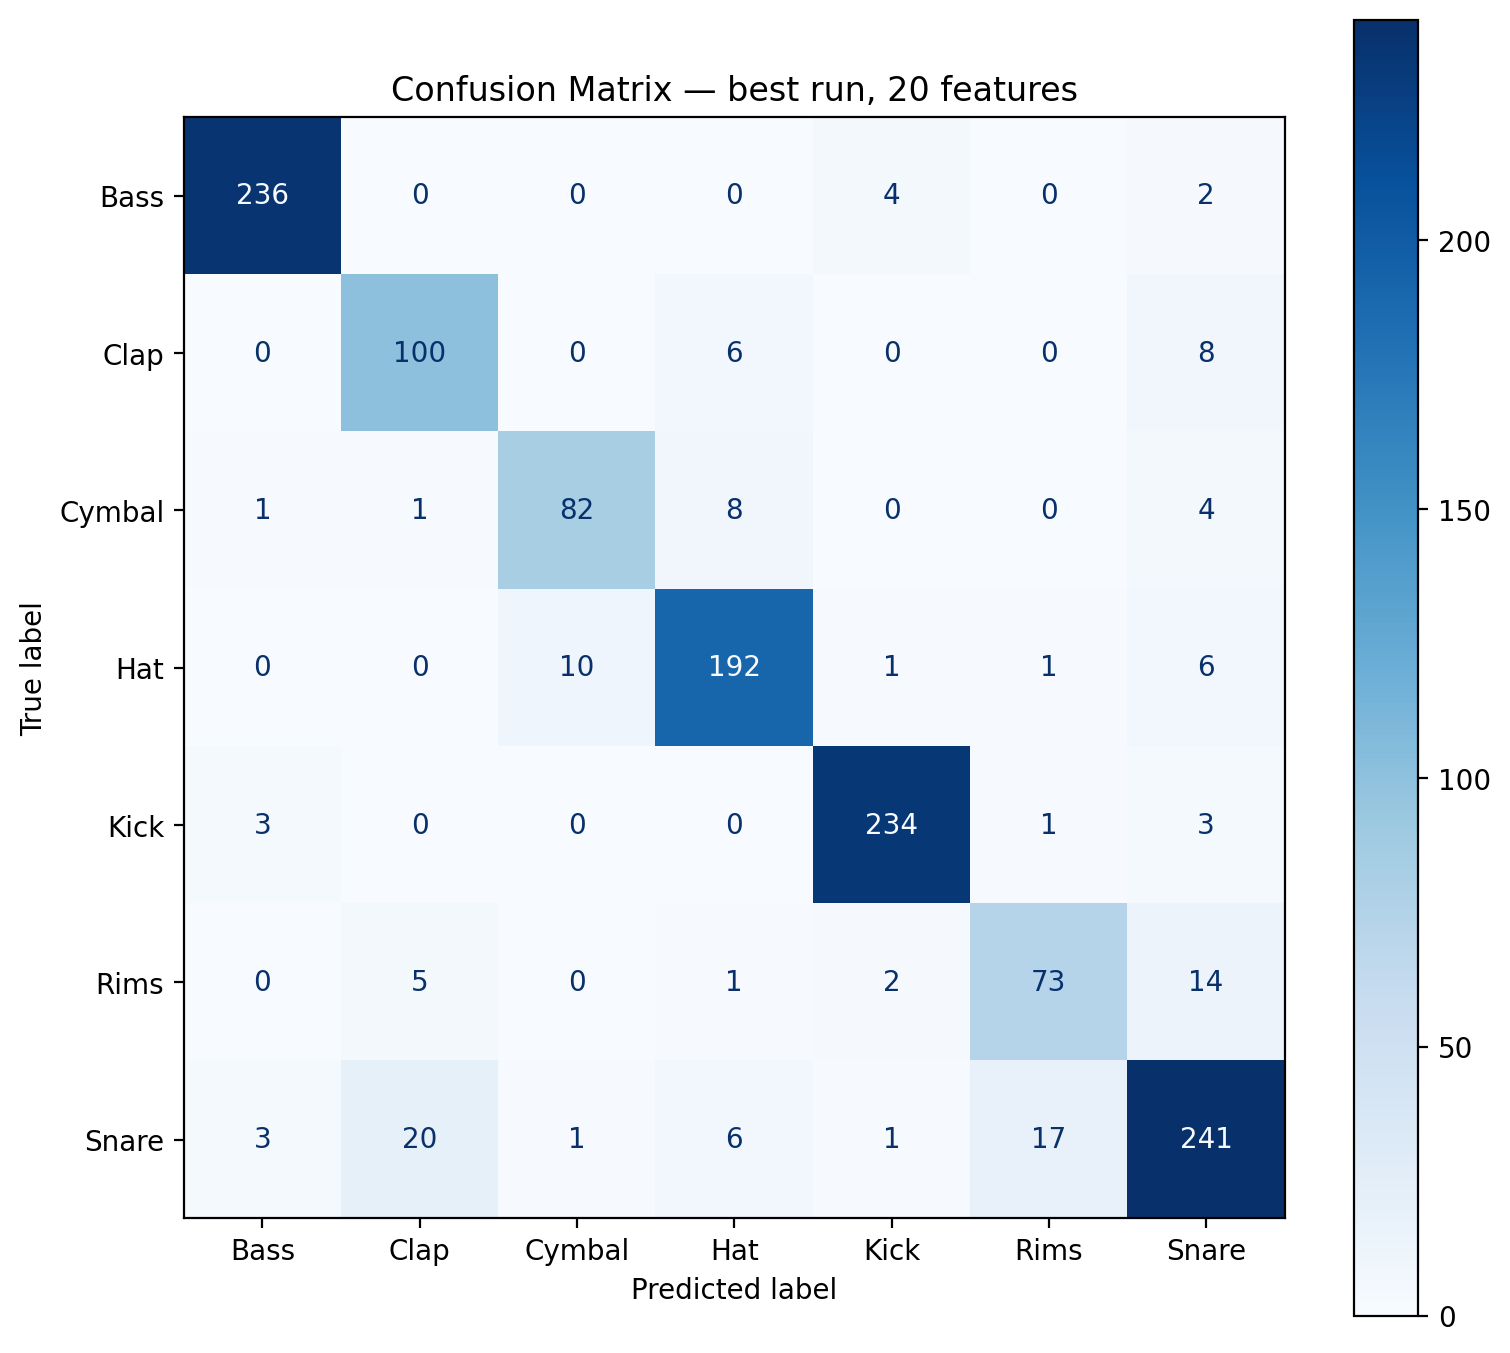

In [19]:

from sklearn.metrics import ConfusionMatrixDisplay

cm = confusion_matrix(y_true, y_pred)

fig, ax = plt.subplots(figsize=(8, 7), dpi=200)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
disp.plot(cmap=plt.cm.Blues, ax=ax, colorbar=True)
ax.set_title('Confusion Matrix — best run, 20 features')
plt.tight_layout()
plt.savefig(f'{SAVE_DIR}/confusion_matrix_20feats.png',
            dpi=300, bbox_inches='tight')
plt.show()


## 9. Training curves — best run + run-to-run variability

The shaded band shows min–max across all 5 runs.


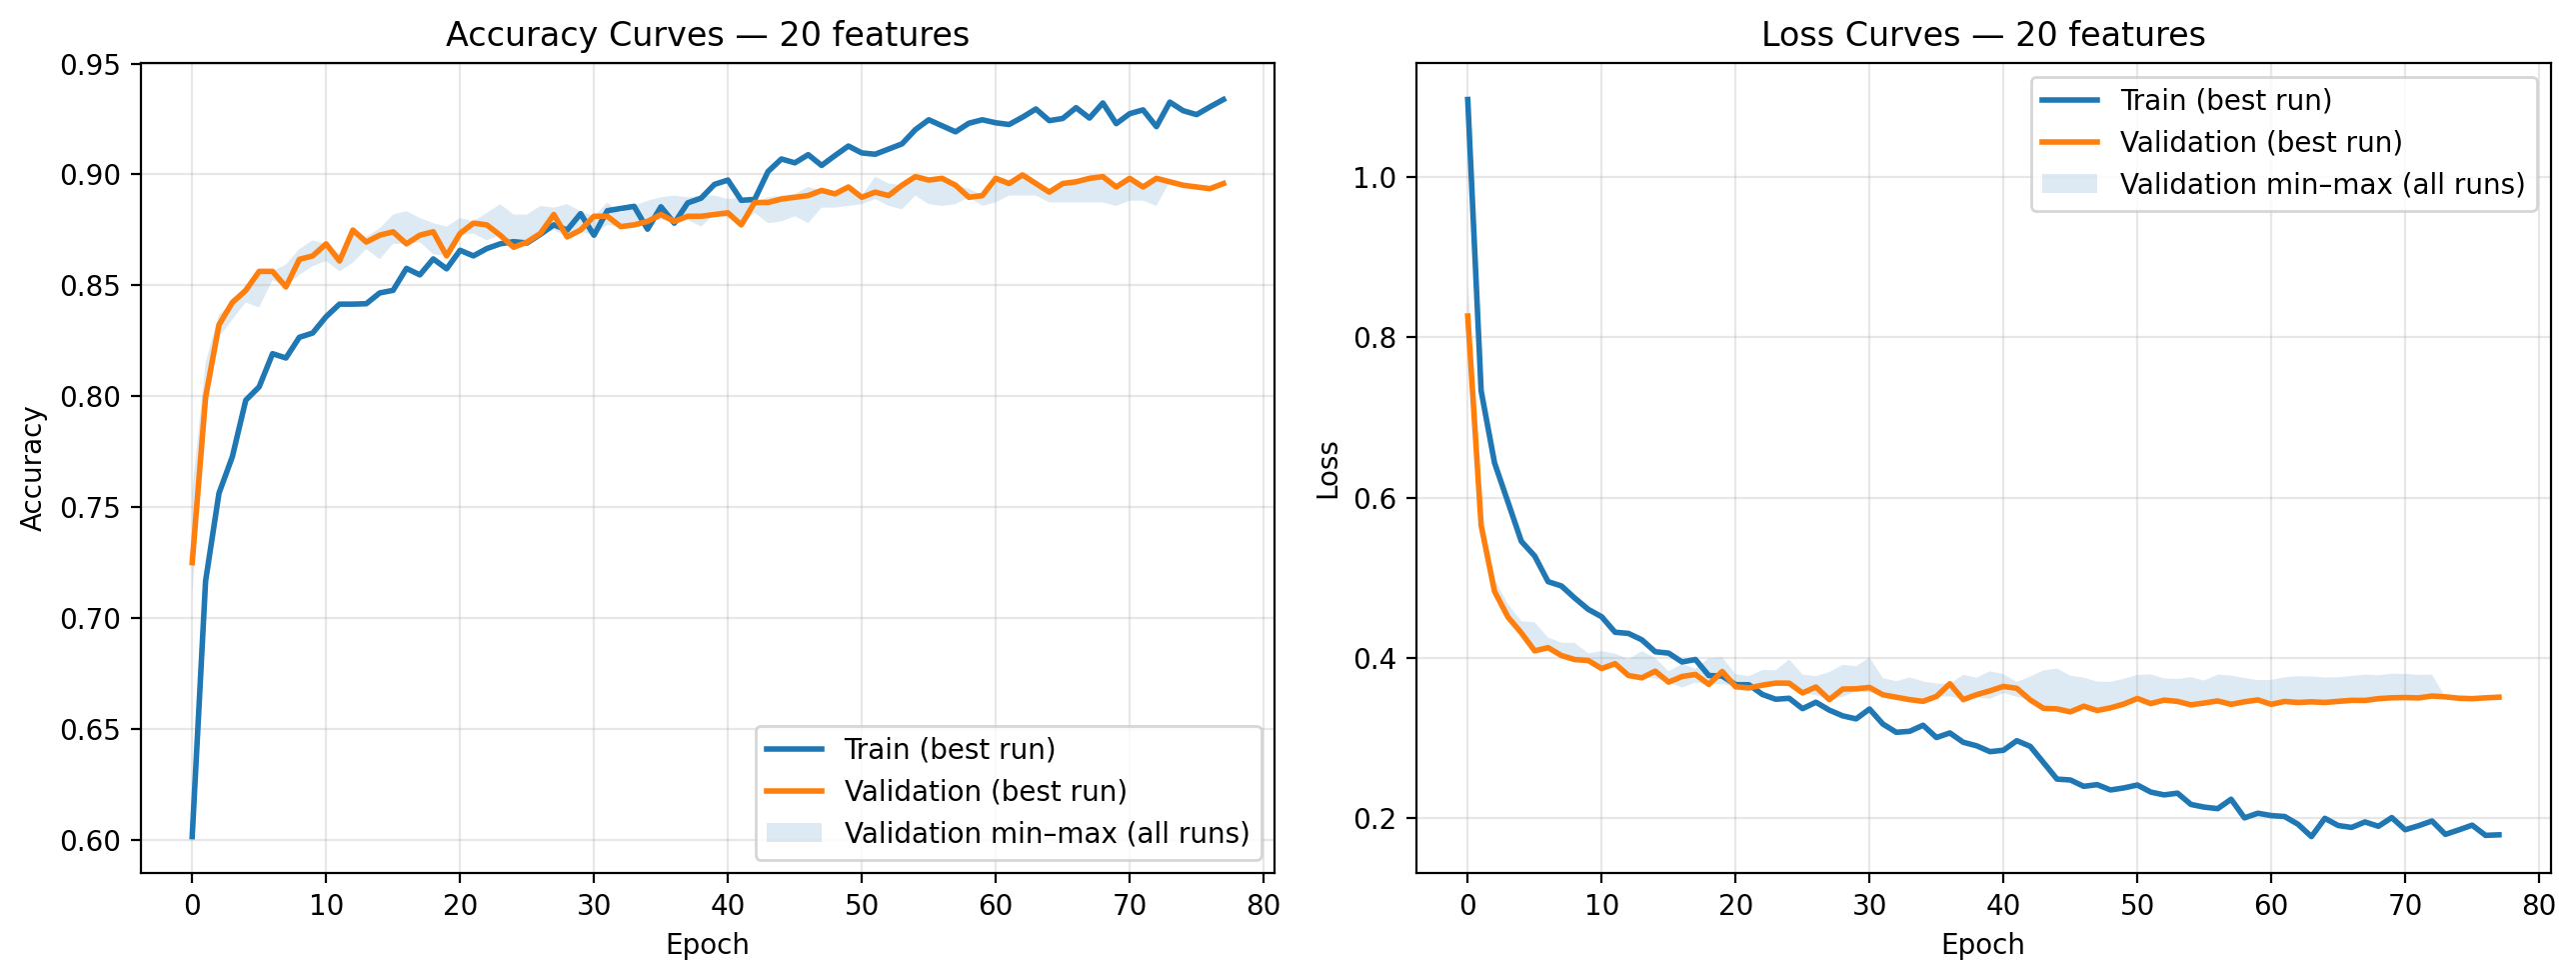

In [20]:

def pad_hist(hist_list, key):
    max_len = max(len(h[key]) for h in hist_list)
    arr = np.full((len(hist_list), max_len), np.nan)
    for i, h in enumerate(hist_list):
        arr[i, :len(h[key])] = h[key]
    return arr

best_hist = all_histories[best_run_idx]

fig, axes = plt.subplots(1, 2, figsize=(13, 5), dpi=200)

# --- Accuracy ---
ax = axes[0]
train_all = pad_hist(all_histories, 'accuracy')
val_all   = pad_hist(all_histories, 'val_accuracy')
epochs_x  = np.arange(train_all.shape[1])

ax.plot(best_hist['accuracy'], label='Train (best run)', lw=2)
ax.plot(best_hist['val_accuracy'], label='Validation (best run)', lw=2)
ax.fill_between(
    epochs_x,
    np.nanmin(val_all, axis=0),
    np.nanmax(val_all, axis=0),
    alpha=0.15,
    label='Validation min–max (all runs)'
)
ax.set_title('Accuracy Curves — 20 features')
ax.set_xlabel('Epoch')
ax.set_ylabel('Accuracy')
ax.legend()
ax.grid(alpha=0.3)

# --- Loss ---
ax = axes[1]
train_loss_all = pad_hist(all_histories, 'loss')
val_loss_all   = pad_hist(all_histories, 'val_loss')
epochs_x2      = np.arange(train_loss_all.shape[1])

ax.plot(best_hist['loss'], label='Train (best run)', lw=2)
ax.plot(best_hist['val_loss'], label='Validation (best run)', lw=2)
ax.fill_between(
    epochs_x2,
    np.nanmin(val_loss_all, axis=0),
    np.nanmax(val_loss_all, axis=0),
    alpha=0.15,
    label='Validation min–max (all runs)'
)
ax.set_title('Loss Curves — 20 features')
ax.set_xlabel('Epoch')
ax.set_ylabel('Loss')
ax.legend()
ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig(f'{SAVE_DIR}/training_curves_20feats_multirun.png',
            dpi=300, bbox_inches='tight')
plt.show()


## Done

Next steps:
1. Paste the `AGGREGATE RESULTS` block, the classification report, and the confusion matrix back into the paper draft.
2. Use the saved best model (`best_20feats.h5`) for any follow-up analysis that specifically needs the top-20 subset.
